# APPLES 3

### IMPORT

In [4]:
import os, sys, warnings
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from arch import arch_model 

warnings.filterwarnings("ignore")
sys.path.append(os.path.abspath('../scripts'))

from spread import SPREAD
from engine import ENGINE
from backtester import BACKTESTER
from tearsheet import TEARSHEET
from screener import SCREENER

### DATA

In [5]:
months = [
    "202501", "202502", "202503", "202504", "202505", "202506",
    "202507", "202508", "202509", "202510", "202511", "202512"
]

my_files = [
    [f"../data/processed/eurusd_dukascopy_ask_{m}.parquet" for m in months],
    [f"../data/processed/eurusd_dukascopy_bid_{m}.parquet" for m in months],
    [f"../data/processed/gbpusd_dukascopy_ask_{m}.parquet" for m in months],
    [f"../data/processed/gbpusd_dukascopy_bid_{m}.parquet" for m in months]
]

### SPREAD

In [6]:
builder = SPREAD(threshold=1000) 
df = builder.build(my_files)

print(df.head(5))

built 23341 rows
                                   Asset_A   Asset_B     Log_A     Log_B  \
timestamp                                                                  
2025-01-02 10:10:01.771000+00:00  1.035330  1.248325  0.034720  0.221803   
2025-01-02 10:13:59.489000+00:00  1.035405  1.248410  0.034793  0.221871   
2025-01-02 10:20:16.682000+00:00  1.035625  1.249145  0.035005  0.222459   
2025-01-02 10:24:22.179000+00:00  1.035350  1.249145  0.034740  0.222459   
2025-01-02 10:28:18.325000+00:00  1.035015  1.248405  0.034416  0.221867   

                                  Return_A  Return_B  
timestamp                                             
2025-01-02 10:10:01.771000+00:00 -0.000193  0.000000  
2025-01-02 10:13:59.489000+00:00  0.000072  0.000068  
2025-01-02 10:20:16.682000+00:00  0.000212  0.000589  
2025-01-02 10:24:22.179000+00:00 -0.000266  0.000000  
2025-01-02 10:28:18.325000+00:00 -0.000324 -0.000593  


### SCREENER

In [7]:
screener = SCREENER(df['Asset_A'], df['Asset_B'])
p_val, hl = screener.generate_report()

     COINTEGRATION SCREENER REPORT      
P-Value:    0.52901 -> fail (not cointegrated)
Half-Life:  596.49 Bars
----------------------------------------
Verdict: DO NOT TRADE. Spread is a random walk.



### ENGINE

In [8]:
df['Date'] = df.index.date
unique_days = df['Date'].unique()

train_days = 30 
print_freq = 10  # Set how often you want a daily update
out_of_sample_results = []
parameter_tracker = [] 

# The Walk-Forward Loop
for i in range(train_days, len(unique_days)):
    train_dates = unique_days[i - train_days : i]
    test_date = unique_days[i]
    
    train_df = df[df['Date'].isin(train_dates)].copy()
    test_df = df[df['Date'] == test_date].copy()
    
    # Fit Models
    engine = ENGINE(train_df)
    train_fitted = engine.fit_cointegration(z_window=250)
    engine.fit_ar_reversion(lags=1)
    engine.fit_garch_vol(scaling=10000)
    engine.fit_markov_regimes(k_regimes=2)
    
    # Predict Out-of-Sample
    oos_predictions = engine.predict_oos(test_df, engine.data, z_window=250)
    out_of_sample_results.append(oos_predictions)
    
    # Track the Daily Parameters
    parameter_tracker.append({
        'Date': test_date,
        'Beta': engine.beta,
        'Alpha': engine.alpha,
        'Safe_Variance': engine.safe_variance,
        'Danger_Variance': engine.danger_variance,
        'GARCH_Vol': engine.forecasted_vol,
        'AR_Phi': engine.ar_phi
    })

    # --- NEW: SMART PRINTOUTS ---
    # 1. Print when a new month rolls over
    if i > train_days and test_date.month != unique_days[i-1].month:
        print(f"\n📅 --- ENTERING {test_date.strftime('%B %Y').upper()} ---")
        
    # 2. Print periodic updates (Every N days)
    if i % print_freq == 0:
        print(f"[{test_date}] Beta: {engine.beta:>6.4f} | GARCH Vol: {engine.forecasted_vol:>5.2f} | AR_Phi: {engine.ar_phi:>6.4f}")

# Stitch data together
live_trading_data = pd.concat(out_of_sample_results)
df_params = pd.DataFrame(parameter_tracker).set_index('Date') 

print(f"\n🎉 OOS Dataset Built: {len(live_trading_data)} rows.")
print("📊 Parameter tracking complete.")

Cointegration Fitted | Beta: 0.5335 | Alpha: -0.0785
Markov Fitted | Danger Variance: 625.02 | Safe Variance: 5.68
[2025-02-13] Beta: 0.5335 | GARCH Vol:  4.79 | AR_Phi: 0.9943
Cointegration Fitted | Beta: 0.5443 | Alpha: -0.0806
Markov Fitted | Danger Variance: 633.99 | Safe Variance: 5.72
Cointegration Fitted | Beta: 0.5578 | Alpha: -0.0832
Markov Fitted | Danger Variance: 660.01 | Safe Variance: 5.84
Cointegration Fitted | Beta: 0.5836 | Alpha: -0.0885
Markov Fitted | Danger Variance: 779.87 | Safe Variance: 5.77
Cointegration Fitted | Beta: 0.6120 | Alpha: -0.0943
Markov Fitted | Danger Variance: 809.65 | Safe Variance: 6.05
Cointegration Fitted | Beta: 0.5991 | Alpha: -0.0913
Markov Fitted | Danger Variance: 785.00 | Safe Variance: 5.87
Cointegration Fitted | Beta: 0.5773 | Alpha: -0.0867
Markov Fitted | Danger Variance: 759.01 | Safe Variance: 5.77
Cointegration Fitted | Beta: 0.5418 | Alpha: -0.0789
Markov Fitted | Danger Variance: 825.07 | Safe Variance: 5.53
Cointegration Fitt

### BACKTESTER

In [9]:
import importlib
import backtester  

importlib.reload(backtester)
from backtester import BACKTESTER

bt = BACKTESTER(live_trading_data)

results_df = bt.run(
    base_z=1.25, 
    exit_z=0.0, 
    danger_threshold=1.1, 
    ar_limit=0.995, 
    fee_bps=0.5,
    stop_loss_bps=100.0,    
    take_profit_bps=25.0,   
    max_hold_bars=150       
)

### TEARSHEET


           INSTITUTIONAL PERFORMANCE REPORT            
Metric                    | Adaptive     | Static Base 
-------------------------------------------------------
Total Return (Bps)        | 1033.96      | 1707.17     
Annual Vol (Bps)          | 586.88       | 697.53      
Sharpe Ratio              | 1.94         | 2.69        
Sortino Ratio             | 1.64         | 2.79        
Max Drawdown (Bps)        | -289.17      | -276.48     
Calmar Ratio              | 3.58         | 6.17        
Win Rate                  | 49.68%       | 50.21%      
Profit Factor             | 1.08         | 1.09        



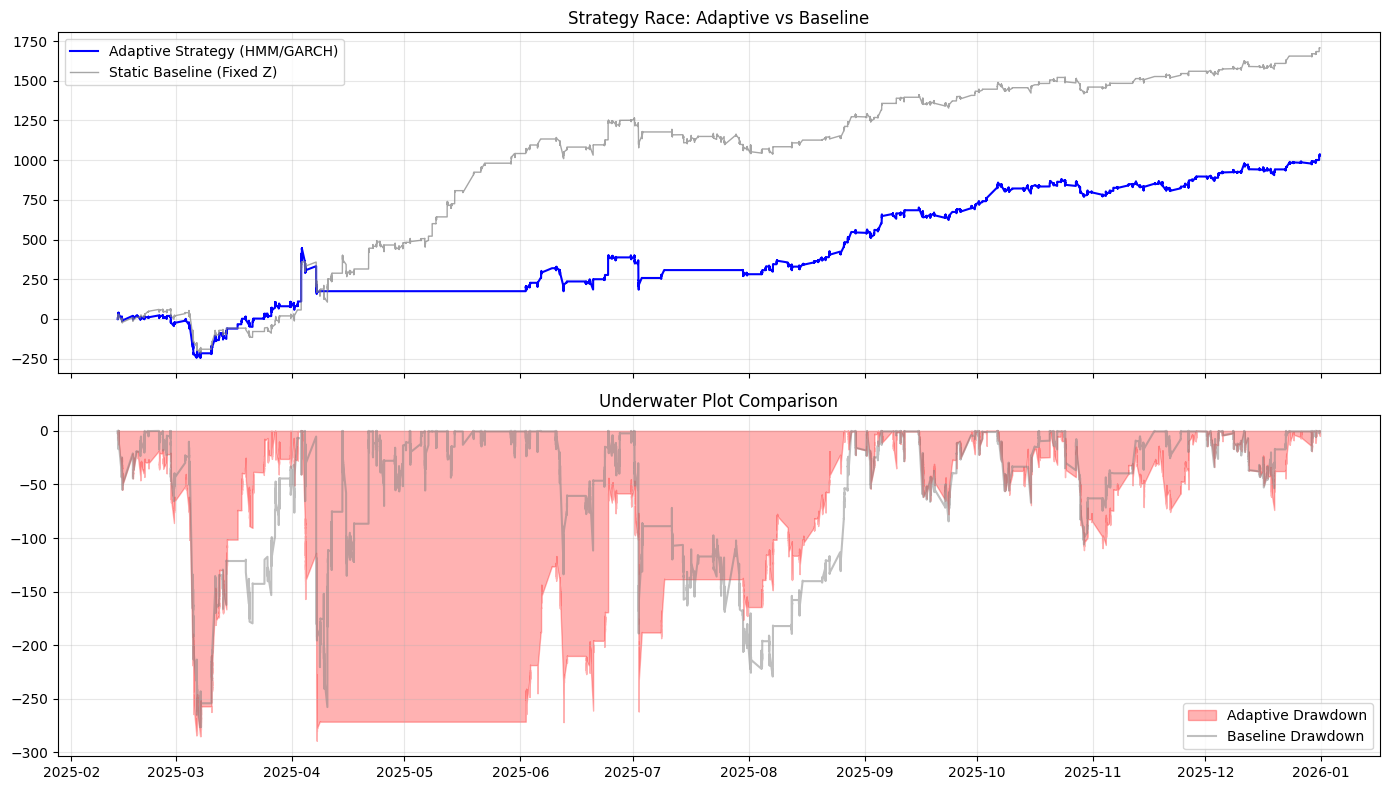

In [10]:
ts = TEARSHEET(results_df, df_params=df_params)
ts.generate_report()
ts.plot_comparative_equity()